# Particle–Gas Deceleration Test (Bai & Stone 2010, §4.2)

Reproduces the particle–gas deceleration test of **Bai & Stone (2010), ApJS 190, 297**
(`ms_method.tex`, *Particle-Gas Deceleration Test*) with the AthenaK dust module
(Yang & Johansen 2016 particle-mesh drag + Krapp et al. 2024 `imex2+`).

**Setup** — a uniform lattice of particles (one per cell) moving at $w_0=+1$ through
uniform gas moving at $-1$ (zero-total-momentum frame), particle-to-gas mass ratio
$\epsilon=1$, back-reaction on. Every particle travels
$$S(t)=\frac{w_0\,t_{\rm stop}}{1+\epsilon}\left[1-e^{-(1+\epsilon)t/t_{\rm stop}}\right],$$
and total momentum must stay zero to round-off.

**Three parts** (matching BS10 Figs. `collision.eps` and `collision2.eps`):
1. *Accuracy*: $t_{\rm stop}=2$, fixed timestep $h$, evolve to $t_e=1$; position error
   $\Delta S(h)$ must converge as $h^2$ and momentum must be conserved to machine
   precision.
2. *Riemann-solver independence*: for spatially uniform states the drag coupling must
   not depend on the solver (`roe`/`hlle`/`llf` identical to round-off).
3. *Stiff regime*: $h=1$ fixed, $t_{\rm stop}=0.2$ and $0.02$ (both $<h$, unresolved).
   A robust integrator must damp the relative velocity **monotonically**, faster for
   smaller $t_{\rm stop}$ — the behavior of BS10's *fully-implicit* integrator. Their
   *semi-implicit* integrator instead oscillates with amplification factor
   $\to-(1-4t_{\rm stop}/h)$, which is why they must switch integrators when
   $t_{\rm stop}\lesssim h$; `imex2+` needs no such switch for stability (the optional
   `gamma_switch` only improves stiff-limit *accuracy*, per Krapp et al. 2024 Eq. 18).

**Infrastructure notes**
- A `<time>/dtmax` cap was added to `Mesh::NewTimeStep` (mesh.hpp/mesh.cpp/
  build_tree.cpp) so runs proceed at exactly constant $h$, as in BS10. The box is huge
  ($8^2$ cells, $\mathrm{d}x=5$) so all stability limits sit above the cap.
- The `dust_damping` problem generator gained a mean-displacement error measurement:
  initial lattice positions are reconstructed from particle tags and compared against
  an RK4 position quadrature (new `err_S` columns in `*-errs.dat`).
- Input: `athenak_dust_tests/inputs/dust_decel.athinput`. Missing data are generated
  automatically; set `RERUN = True` below to force regeneration.

**On "roe required"** — for this test the Riemann solver is *provably irrelevant*
(uniform states have no flux differences), and part 2 confirms it numerically. The
`rsolver = roe` requirement for streaming-instability runs is therefore *not* a drag-
scheme robustness issue: it is the usual diffusivity of 2-wave solvers (HLLE/LLF) acting
on marginally-resolved waves. Note AthenaK rejects `hllc` for isothermal EOS outright
(`hydro.cpp`: HLLC's restored middle wave is implemented for ideal EOS only), so the
isothermal choices are `llf`/`hlle`/`roe`, and only Roe retains the full wave fan.

## Test setup

### Problem generator

All cases use the built-in `dust_damping` problem generator in
`athenak/src/pgen/tests/dust_damping.cpp`, including its particle-displacement diagnostics.
AthenaK is compiled with `-DPROBLEM=built_in_pgens`, and the input selects the generator with
`<problem>/pgen_name = dust_damping`.

### CPU build

From the directory containing both `athenak/` and `athenak_dust_tests/`:

```bash
cmake -S athenak -B athenak/build \
  -DCMAKE_BUILD_TYPE=Release \
  -DPROBLEM=built_in_pgens
cmake --build athenak/build -j
```

The notebook performs this build if `athenak/build/src/athena` is missing.

### Input and execution

The tracked input is `athenak_dust_tests/inputs/dust_decel.athinput`. The notebook applies the
timestep, stopping-time, loading, placement, resolution, and solver variants as command-line
overrides, so the tracked file remains unchanged. Start Jupyter from the directory containing
both repositories, open this notebook, and select **Run All**. Missing results are generated and
existing results are reused; set `RERUN = True` to force regeneration. Inputs, histories, error
tables, and plots are produced from files under `athenak/build/run-dust/`.

In [1]:
import os, subprocess
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if not (ROOT/'athenak').is_dir() and (ROOT/'athenak_cc'/'athenak').is_dir():
    ROOT = ROOT/'athenak_cc'
assert (ROOT/'athenak').is_dir() and (ROOT/'athenak_dust_tests').is_dir(), \
    'start Jupyter from the directory containing athenak/ and athenak_dust_tests/, or its parent'
RUNDIR = str(ROOT/'athenak/build/run-dust')
EXE    = str(ROOT/'athenak/build/src/athena')
INP    = str(ROOT/'athenak_dust_tests/inputs/dust_decel.athinput')
os.makedirs(RUNDIR, exist_ok=True)
RERUN  = False   # True: regenerate all data files in RUNDIR

if not os.path.exists(EXE):
    subprocess.run(['cmake','-S',str(ROOT/'athenak'),'-B',str(ROOT/'athenak/build'),
                    '-DCMAKE_BUILD_TYPE=Release','-DPROBLEM=built_in_pgens'], check=True)
    subprocess.run(['cmake','--build',str(ROOT/'athenak/build'),'-j8'], check=True)

def run(*overrides):
    cmd = [EXE, '-i', INP] + list(overrides)
    subprocess.run(cmd, cwd=RUNDIR, check=True, capture_output=True)

baseline_outputs = [
    'dust_decel-errs.dat', 'dust_decel_solv-errs.dat',
    'stiff_ts0.2_gsfalse.user.hst', 'stiff_ts0.2_gstrue.user.hst',
    'stiff_ts0.02_gsfalse.user.hst', 'stiff_ts0.02_gstrue.user.hst',
]
if RERUN or not all(os.path.exists(os.path.join(RUNDIR, f)) for f in baseline_outputs):
    for f in ['dust_decel-errs.dat', 'dust_decel_solv-errs.dat']:
        p = os.path.join(RUNDIR, f)
        if os.path.exists(p): os.remove(p)
    for k in range(11):                                   # accuracy scan h = 2^-k
        run(f'time/dtmax={0.5**k!s}')
    for rs in ['roe', 'hlle', 'llf']:                     # solver independence
        run('time/dtmax=0.25', f'hydro/rsolver={rs}', 'job/basename=dust_decel_solv')
    for ts in ['0.2', '0.02']:                            # stiff regime
        for gs in ['false', 'true']:
            run('time/dtmax=1.0', 'time/tlim=10.0', f'dust/taus_1={ts}',
                f'dust/gamma_switch={gs}', f'job/basename=stiff_ts{ts}_gs{gs}')

ok_all = True
def verdict(ok, msg):
    global ok_all; ok_all &= ok
    print(('PASS' if ok else 'FAIL') + '  ' + msg)
    return ok


## 1. Accuracy: position error and momentum conservation vs $h$

BS10 Fig. `collision.eps`: cumulative position error $\Delta S$ at $t_e=1$ must scale
as $h^2$; total momentum must be conserved to machine accuracy at every $h$.


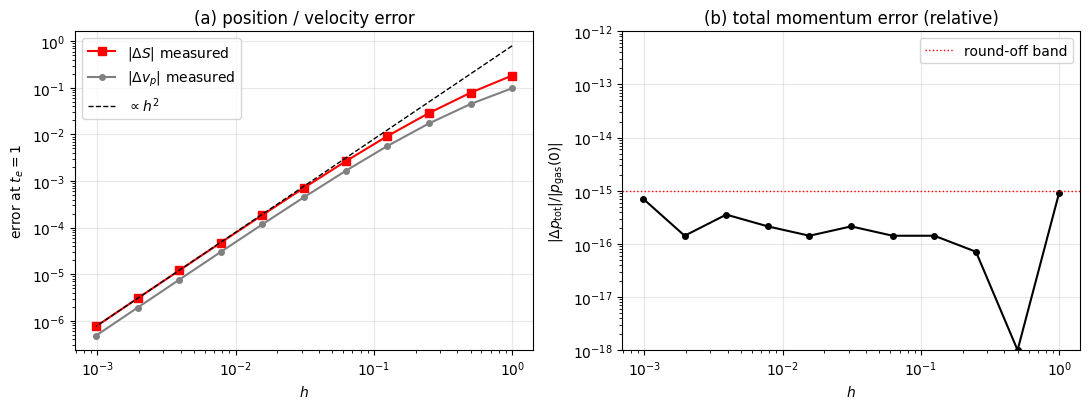

measured convergence order: position 1.991, velocity 1.990
PASS  position error converges as h^2 (BS10 Fig. collision-a)
PASS  velocity error converges as h^2
PASS  total momentum conserved to round-off at every h (BS10 Fig. collision-b)
PASS  gas and dust velocity errors identical (forced by momentum conservation, eps=1)


True

In [2]:
E = np.loadtxt(os.path.join(RUNDIR, 'dust_decel-errs.dat'))
ncyc = E[:, 3]; h = 1.0/ncyc
err_u, err_v, err_mom, err_S = E[:, 4], E[:, 5], E[:, 6], E[:, 7]

# gas momentum scale for a relative measure: |p_gas| = rho0*|v|*V = 1*1*40^2
pscale = 40.0**2

fig, axs = plt.subplots(1, 2, figsize=(11, 4.2))
axs[0].loglog(h, err_S, 'rs-', label=r'$|\Delta S|$ measured')
axs[0].loglog(h, err_v, 'o-', color='gray', ms=4, label=r'$|\Delta v_p|$ measured')
axs[0].loglog(h, err_S[-1]*(h/h[-1])**2, 'k--', lw=1, label=r'$\propto h^2$')
axs[0].set_xlabel('$h$'); axs[0].set_ylabel('error at $t_e=1$')
axs[0].set_title('(a) position / velocity error')
axs[0].legend(); axs[0].grid(alpha=0.3)
axs[1].loglog(h, np.maximum(err_mom/pscale, 1e-18), 'ko-', ms=4)
axs[1].axhline(1e-15, color='r', ls=':', lw=1, label='round-off band')
axs[1].set_xlabel('$h$'); axs[1].set_ylabel(r'$|\Delta p_{\rm tot}|/|p_{\rm gas}(0)|$')
axs[1].set_title('(b) total momentum error (relative)')
axs[1].set_ylim(1e-18, 1e-12); axs[1].legend(); axs[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# convergence order from the last 4 points of the scan
p_S = np.polyfit(np.log(h[-4:]), np.log(err_S[-4:]), 1)[0]
p_v = np.polyfit(np.log(h[-4:]), np.log(err_v[-4:]), 1)[0]
print(f'measured convergence order: position {p_S:.3f}, velocity {p_v:.3f}')
verdict(abs(p_S - 2.0) < 0.1, 'position error converges as h^2 (BS10 Fig. collision-a)')
verdict(abs(p_v - 2.0) < 0.1, 'velocity error converges as h^2')
verdict(np.all(err_mom/pscale < 1e-14),
        'total momentum conserved to round-off at every h (BS10 Fig. collision-b)')
verdict(np.allclose(err_u, err_v, rtol=1e-12),
        'gas and dust velocity errors identical (forced by momentum conservation, eps=1)')


## 2. Riemann-solver independence of the drag coupling

Same run ($h=0.25$) with `roe`, `hlle`, `llf`. For uniform states the flux differences
vanish, so **any** difference here would expose a spurious solver dependence in the
drag/deposit pipeline.


In [3]:
S = np.loadtxt(os.path.join(RUNDIR, 'dust_decel_solv-errs.dat'))
for row, name in zip(S, ['roe ', 'hlle', 'llf ']):
    print(f'{name}:  err_v = {row[5]:.6e}   err_S = {row[7]:.6e}   '
          f'err_mom = {row[6]:.2e}')
verdict(np.all(S[:, 5] == S[0, 5]) and np.all(S[:, 7] == S[0, 7]),
        'roe/hlle/llf give bit-identical velocity and position errors')


roe :  err_v = 1.714264e-02   err_S = 2.867820e-02   err_mom = 1.14e-13
hlle:  err_v = 1.714264e-02   err_S = 2.867820e-02   err_mom = 1.14e-13
llf :  err_v = 1.714264e-02   err_S = 2.867820e-02   err_mom = 0.00e+00
PASS  roe/hlle/llf give bit-identical velocity and position errors


np.True_

## 3. Stiff regime: $h=1$, $t_{\rm stop} = 0.2$ and $0.02$

BS10 Fig. `collision2.eps`. Requirements for a robust scheme (their fully-implicit
panel b): monotone decay with **no oscillation**, and *faster* damping for *smaller*
$t_{\rm stop}$. The measured per-step decay factors are also compared against the
exact `imex2+` update map (the same map validated to $7\times10^{-15}$ in
`dust_validation.ipynb`).


  ts    gamma_switch   measured factor   exact imex2+ map
  0.2    false          +0.076990        +0.076990
  0.02   false          +0.008222        +0.008222
  0.2    true           +0.027778        +0.027778
  0.02   true           +0.000384        +0.000384


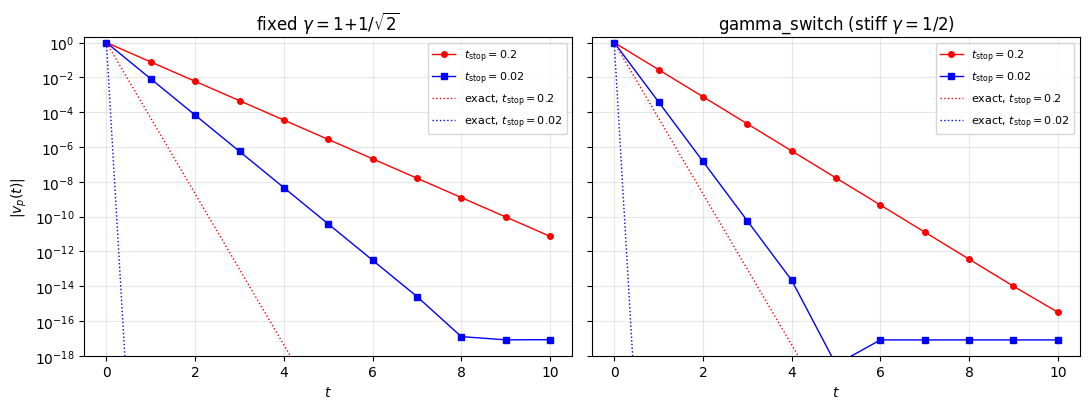

PASS  monotone positive decay, no oscillation (unlike BS10 semi-implicit)
PASS  smaller t_stop damps faster (BS10 fully-implicit behavior)
PASS  measured per-step factors equal the exact imex2+ map to <1e-6


np.True_

In [4]:
def imex2p_factor(ts, eps, dt, gamma):
    """Exact one-step map of imex2+ for the pure-drag system; returns v1/v0 in the
    zero-momentum frame (u0 = -eps*v0)."""
    g = gamma
    g0 = (2*g - 1)/(2*g*g); g1 = 1 - g0
    a22 = (1 - 2*g*g)/(2*g)
    u, v = -eps*1.0, 1.0
    un, vn = u, v
    a = g*dt; c = a/(ts + a)
    ust = (u + eps*c*v)/(1 + eps*c)
    dv = c*(ust - v); v1 = v + dv; Rs = dv/a; Ru = (ust - u)/a
    ub = g0*ust + g1*un + a22*dt*Ru
    vb = g0*v1 + g1*vn + a22*dt*Rs
    ust2 = (ub + eps*c*vb)/(1 + eps*c)
    return vb + c*(ust2 - vb)

GAM = 1.0 + 1.0/np.sqrt(2.0)
fig, axs = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
styles = {('0.2','false'): ('r-o', 0), ('0.02','false'): ('b-s', 0),
          ('0.2','true'):  ('r-o', 1), ('0.02','true'):  ('b-s', 1)}
ok_mono, ok_trend, ok_map = True, True, True
print('  ts    gamma_switch   measured factor   exact imex2+ map')
for (ts, gs), (st, ipanel) in styles.items():
    d = np.loadtxt(os.path.join(RUNDIR, f'stiff_ts{ts}_gs{gs}.user.hst'))
    _, iu = np.unique(d[:, 0], return_index=True)   # drop duplicated final hst row
    d = d[np.sort(iu)]
    t, v = d[:, 0], d[:, 2]/d[:, 3]
    axs[ipanel].semilogy(t, np.abs(v), st, ms=4, lw=1,
                         label=rf'$t_{{\rm stop}}={ts}$')
    # measured per-step factor while well above round-off
    mask = np.abs(v) > 1e-13
    fac = (v[1:]/v[:-1])[mask[1:]][0]
    gam = 0.5 if gs == 'true' else GAM
    fmap = imex2p_factor(float(ts), 1.0, 1.0, gam)
    print(f'  {ts:5s}  {gs:5s}          {fac:+.6f}        {fmap:+.6f}')
    ok_map  &= abs(fac/fmap - 1.0) < 1e-6
    vv = v[np.abs(v) > 1e-13]
    ok_mono &= np.all(vv > 0) and np.all(np.diff(vv) < 0)
for ipanel, ttl in [(0, r'fixed $\gamma = 1{+}1/\sqrt{2}$'),
                    (1, r'gamma_switch (stiff $\gamma = 1/2$)')]:
    tt = np.linspace(0, 10, 200)
    for ts, cl in [(0.2, 'r'), (0.02, 'b')]:
        axs[ipanel].semilogy(tt, np.exp(-2*tt/ts), cl + ':', lw=1,
                             label=rf'exact, $t_{{\rm stop}}={ts}$')
    axs[ipanel].set_title(ttl); axs[ipanel].set_xlabel(r'$t$')
    axs[ipanel].grid(alpha=0.3); axs[ipanel].legend(fontsize=8)
axs[0].set_ylabel(r'$|v_p(t)|$'); axs[0].set_ylim(1e-18, 2)
plt.tight_layout(); plt.show()

# trend: smaller ts must damp FASTER (BS10 fully-implicit behavior, panel b)
f02  = np.loadtxt(os.path.join(RUNDIR, 'stiff_ts0.2_gsfalse.user.hst'))
f002 = np.loadtxt(os.path.join(RUNDIR, 'stiff_ts0.02_gsfalse.user.hst'))
r02  = (f02[2, 2]/f02[2, 3])/(f02[1, 2]/f02[1, 3])
r002 = (f002[2, 2]/f002[2, 3])/(f002[1, 2]/f002[1, 3])
ok_trend = r002 < r02
verdict(ok_mono, 'monotone positive decay, no oscillation (unlike BS10 semi-implicit)')
verdict(ok_trend, 'smaller t_stop damps faster (BS10 fully-implicit behavior)')
verdict(ok_map, 'measured per-step factors equal the exact imex2+ map to <1e-6')


## 4. Numerical exercise: 1.5 particles per cell

Two placements with the same mean load of 1.5 ppc (96 particles on the 8$\times$8
grid), probing how the convergence behavior depends on the *roughness* of the TSC
deposit field:

- **Uniform spacing**: a regular 12$\times$8 lattice per block (spacing
  $\tfrac{2}{3}\mathrm{d}x$ in $x$, $\mathrm{d}x$ in $y$; pgen mode
  `lat_nx1/lat_nx2`). The TSC deposit of this incommensurate comb is uniform except
  for a deterministic Nyquist ripple in $x$ of amplitude
  $[\sin(3\pi/2)/(3\pi/2)]^3 \approx 0.96\%$ (the $3\pi/\mathrm{d}x$ comb
  mode aliased to the grid).
- **Random**: Poisson placement (fixed RNG seed), deposit fluctuations
  $\sim25\%$ rms after TSC smoothing.

In both cases the spatially uniform damping ODE is no longer the exact continuum
limit, so two error measures are separated: (1) error vs the uniform-ODE reference,
which must flatten at a *sampling floor* (a property of the reference, not the
integrator), and (2) Richardson self-convergence $|\bar v(h)-\bar v(h/2)|$, which
isolates pure time discretization.

**Measured:**

| placement | deposit roughness | ODE floor | self-convergence |
|---|---|---|---|
| ppc=1 lattice | 0 | none ($h^2$ throughout) | $h^2$ |
| ppc=1.5 uniform | 0.96% ripple | $1.5\times10^{-5}$ | **pure $h^2$ to $h=2^{-14}$** |
| ppc=1.5 random | ~25% | $1.9\times10^{-2}$ | $h^2$ until $h\approx0.02$, then 1st-order tail $B\approx9\times10^{-3}$ |

Both the ODE floor and the first-order coefficient scale roughly **quadratically**
with the deposit roughness ($26\times$ smaller ripple $\to$ ~$10^3\times$ smaller
floor; $B$ drops below measurability). The first-order tail of the random case was
investigated separately: it is not the Riemann solver (hlle/llf identical), not PLM
limiter switching (donor-cell identical), not the sonic coincidence $|v_g|=c_s$
(velocity shift rescales but keeps it), and deposits use stage-current positions
(task order `ExplicitPush -> DepositDrag -> Solve -> GatherKickPMBR`).
**Mechanism (identified 2026-07-16 via external review, confirmed against the code
and these measurements)**: the per-cell closed-form $u^\star$ solve is not the
exact resolvent of the coupled TSC particle–mesh implicit stage — the true stage
equation $[M_g + G^T M_p C\,G]\,u^\star = q_g + G^T M_p C\,q_p$ carries
cross-cell $W_{jk}W_{j\ell}$ coupling that the per-cell denominator drops. The
defect vanishes for NGP and for spatially uniform deposits (hence $B=0$ on the
integer lattice) and grows with deposit roughness (hence the ~quadratic
suppression at the 1% ripple), so Krapp's 2nd-order proof does not transfer to
general TSC states. Practical impact is negligible ($Bh\sim10^{-7}$ at typical SI
timesteps even in the random case). Planned fix: a matrix-free SPD CG stage solve
(`hand-off.md` issue 0); the acceptance test is this scan with $B\to0$.


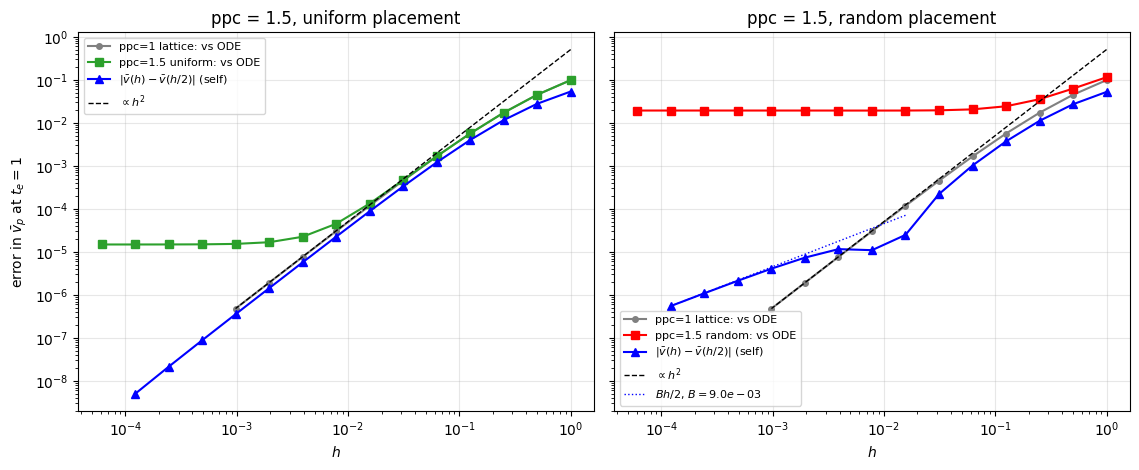

--- ppc=1.5 uniform ---
   h          err vs ODE   local slope   v(h)-v(h/2)   ratio to next
1.000e+00   9.807e-02        nan     +5.324e-02       1.924
5.000e-01   4.483e-02      1.129     +2.768e-02       2.403
2.500e-01   1.716e-02      1.386     +1.152e-02       2.897
1.250e-01   5.638e-03      1.605     +3.975e-03       3.317
6.250e-02   1.663e-03      1.762     +1.199e-03       3.612
3.125e-02   4.641e-04      1.841     +3.318e-04       3.793
1.562e-02   1.323e-04      1.810     +8.747e-05       3.895
7.812e-03   4.486e-05      1.561     +2.246e-05       3.952
3.906e-03   2.241e-05      1.002     +5.683e-06       3.987
1.953e-03   1.672e-05      0.422     +1.425e-06       4.015
9.766e-04   1.530e-05      0.129     +3.550e-07       4.053
4.883e-04   1.494e-05      0.034     +8.759e-08       4.120
2.441e-04   1.486e-05      0.008     +2.126e-08       4.261
1.221e-04   1.484e-05      0.002     +4.989e-09         nan
6.104e-05   1.483e-05      0.000          -            -

--- ppc=1

np.True_

In [5]:
import glob
KS = list(range(15))          # h = 1 ... 2^-14

CASES = {
    'random':  ('decel_ppc15_h',  ['particles/ppc=1.5', 'problem/lattice=false']),
    'uniform': ('decel_ppc15u_h', ['particles/ppc=1.5', 'problem/lattice=false',
                                   'problem/lat_nx1=12', 'problem/lat_nx2=8']),
}

def missing(base):
    return not all(
        os.path.exists(os.path.join(RUNDIR, f'{base}{k}.user.hst')) for k in KS)

dat = {}
for name, (base, opts) in CASES.items():
    if RERUN or missing(base):
        for k in KS:
            for f in glob.glob(os.path.join(RUNDIR, f'{base}{k}*')):
                os.remove(f)
            run(f'time/dtmax={0.5**k!s}', *opts, f'job/basename={base}{k}')
    hh, ev, em, vb = [], [], [], []
    for k in KS:
        r = np.loadtxt(os.path.join(RUNDIR, f'{base}{k}-errs.dat'))
        hst = np.loadtxt(os.path.join(RUNDIR, f'{base}{k}.user.hst'))
        assert abs(hst[-1, 0] - 1.0) < 1e-12
        hh.append(1.0/r[3]); ev.append(r[5]); em.append(r[6])
        vb.append(hst[-1, 2]/hst[-1, 3])
    hh, ev, em, vb = map(np.array, (hh, ev, em, vb))
    dat[name] = dict(h=hh, ev=ev, em=em, vb=vb,
                     ds=vb[:-1] - vb[1:], es=np.abs(vb[:-1] - vb[1:]))

fig, axs = plt.subplots(1, 2, figsize=(11.5, 4.8), sharey=True)
for ax, name, col in [(axs[0], 'uniform', 'tab:green'), (axs[1], 'random', 'r')]:
    d = dat[name]
    ax.loglog(h, err_v, 'o-', color='gray', ms=4, label='ppc=1 lattice: vs ODE')
    ax.loglog(d['h'], d['ev'], 's-', color=col, label=f'ppc=1.5 {name}: vs ODE')
    ax.loglog(d['h'][:-1], d['es'], '^-', color='b',
              label=r'$|\bar v(h)-\bar v(h/2)|$ (self)')
    ax.loglog(h, err_v[-1]*(h/h[-1])**2, 'k--', lw=1, label=r'$\propto h^2$')
    if name == 'random':
        B = 2*d['es'][-1]/d['h'][-2]
        ax.loglog(d['h'][6:-1], B*d['h'][6:-1]/2, 'b:', lw=1,
                  label=rf'$Bh/2$, $B={B:.1e}$')
    ax.set_xlabel('$h$'); ax.set_title(f'ppc = 1.5, {name} placement')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
axs[0].set_ylabel(r'error in $\bar v_p$ at $t_e=1$')
plt.tight_layout(); plt.show()

for name in ['uniform', 'random']:
    d = dat[name]
    print(f'--- ppc=1.5 {name} ---')
    print('   h          err vs ODE   local slope   v(h)-v(h/2)   ratio to next')
    for i in range(len(KS)):
        s_ode = (np.log(d['ev'][i-1]/d['ev'][i])/np.log(2) if i > 0 else np.nan)
        if i < len(d['ds']):
            rat = (d['es'][i]/d['es'][i+1] if i+1 < len(d['es']) else np.nan)
            tail = f"{d['ds'][i]:+.3e}    {rat:8.3f}"
        else:
            tail = '     -            -'
        print(f"{d['h'][i]:.3e}   {d['ev'][i]:.3e}   {s_ode:8.3f}     {tail}")
    print()

du, dr = dat['uniform'], dat['random']
ratios_u = du['es'][-6:-1]/du['es'][-5:]
p_tail_r = np.polyfit(np.log(dr['h'][:-1][-4:]), np.log(dr['es'][-4:]), 1)[0]
B = 2*dr['es'][-1]/dr['h'][-2]
print(f'uniform: self-convergence ratios (last 5): '
      + '  '.join(f'{r:.2f}' for r in ratios_u))
print(f"uniform: ODE floor {du['ev'][-1]:.2e};   "
      f"random: ODE floor {dr['ev'][-1]:.2e}, "
      f'1st-order tail order {p_tail_r:.3f}, B = {B:.2e}')
verdict(np.all(du['em']/pscale < 1e-14) and np.all(dr['em']/pscale < 1e-14),
        'total momentum conserved to round-off in both ppc=1.5 placements')
verdict(np.all((ratios_u > 3.5) & (ratios_u < 4.6)),
        'UNIFORM spacing: self-convergence is pure 2nd order to h=2^-14 '
        '(no measurable 1st-order tail at the 1% deposit ripple)')
verdict(du['ev'][-1] < 1e-4,
        'uniform-spacing ODE floor ~1.5e-5, ~1000x below the random floor: '
        'both floors scale ~quadratically with deposit roughness')
rr = dr['es'][-3:-1]/dr['es'][-2:]
verdict(np.all((rr > 1.7) & (rr < 2.3)),
        'RANDOM placement: asymptotically clean 1st order (B~9e-3 tail; no floor, '
        'no instability)')


## 5. Deceleration test vs grid resolution (1 ppc and 1.5 ppc)

Fixed box ($L=40$), resolutions $N = 8 \dots 1024$, single MeshBlock, timestep set
by the hydro CFL ($h \propto \Delta x$, the `dtmax` cap lifted) — i.e. the
convergence a user actually gets when refining the grid. Errors at $t_e=1$ vs the
RK4 ODE reference, for the 1 ppc integer lattice and the 1.5 ppc uniform-spacing
lattice ($\mathtt{lat\_nx1} = 3N/2$).

What to expect: for 1 ppc the deposit field is exactly uniform at **every** $N$, so
the spatial error is identically zero and this scan measures the temporal order
through $h \propto \Delta x$. For 1.5 ppc the 0.96% deposit ripple adds a genuine
spatial (particle-sampling) contribution — the question is whether it degrades the
observed order. Measured: it does not; the two cases agree to 3+ digits at every
$N$ (the placement-induced difference $|\bar v_{1{\rm ppc}} -
\bar v_{1.5{\rm ppc}}|$ decays from $\sim10^{-4}$ at $N\le64$ to
$\sim10^{-7}$ by $N \ge 128$), and both converge at 2nd order (order 1.93 at
$N=1024$; it approaches 2 slowly from below because coarse grids run only 1–12
cycles and the final step is clipped to hit $t_e$ exactly).

Momentum note: the 1 ppc column shows *exact zeros* because every cell performs
identical arithmetic and round-off cancels structurally; with the ripple broken
symmetry the error accumulates as ordinary round-off over
$\mathcal{O}(10^6)$-term reductions ($\sim3\times10^{-12}$ relative at
$N=1024$ — far below any physical scale).


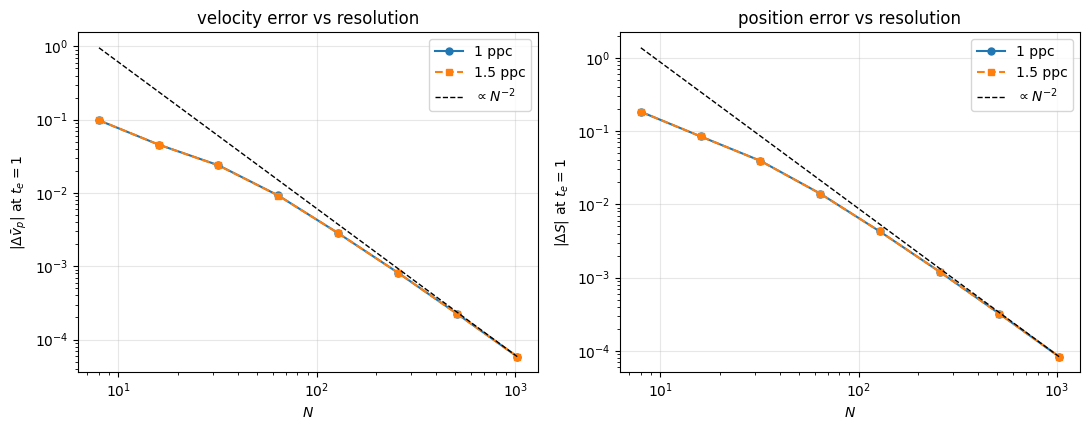

   N     1ppc err_v   order   1.5ppc err_v  order    vbar(1)-vbar(1.5)
    8   9.8007e-02     nan   9.8068e-02     nan     -6.115e-05
   16   4.5620e-02    1.10   4.5666e-02    1.10     -4.600e-05
   32   2.3863e-02    0.93   2.3703e-02    0.95     +1.606e-04
   64   9.2405e-03    1.37   9.2100e-03    1.36     +3.046e-05
  128   2.8390e-03    1.70   2.8388e-03    1.70     +2.568e-07
  256   8.2019e-04    1.79   8.1945e-04    1.79     +7.414e-07
  512   2.2250e-04    1.88   2.2228e-04    1.88     +2.219e-07
 1024   5.8446e-05    1.93   5.8340e-05    1.93     +1.059e-07

fitted orders (last 3 points):  1 ppc: v 1.91, S 1.93;   1.5 ppc: v 1.91, S 1.93
PASS  both 1 ppc and 1.5 ppc converge at 2nd order in grid resolution (CFL-coupled dt)
PASS  placement-induced (spatial sampling) difference decays below 1e-5 for N >= 128: the deposit ripple never intrudes on the convergence
PASS  momentum conserved to (accumulated) round-off at every resolution


np.True_

In [6]:
NS = [8, 16, 32, 64, 128, 256, 512, 1024]
RCASES = {'1 ppc':   ('decel_res1_N',  []),
          '1.5 ppc': ('decel_res15_N', ['particles/ppc=1.5', 'problem/lattice=false'])}

rdat = {}
for name, (base, opts) in RCASES.items():
    ev, eS, em, vbN = [], [], [], []
    for N in NS:
        fe = os.path.join(RUNDIR, f'{base}{N}-errs.dat')
        if RERUN or not os.path.exists(fe):
            extra = ([f'problem/lat_nx1={3*N//2}', f'problem/lat_nx2={N}']
                     if '1.5' in name else [])
            if os.path.exists(fe): os.remove(fe)
            run(f'mesh/nx1={N}', f'mesh/nx2={N}', f'meshblock/nx1={N}',
                f'meshblock/nx2={N}', 'time/dtmax=1000.0', *opts, *extra,
                f'job/basename={base}{N}')
        r = np.loadtxt(fe)
        hst = np.loadtxt(os.path.join(RUNDIR, f'{base}{N}.user.hst'))
        ev.append(r[5]); eS.append(r[7]); em.append(r[6])
        vbN.append(hst[-1, 2]/hst[-1, 3])
    rdat[name] = dict(ev=np.array(ev), eS=np.array(eS), em=np.array(em),
                      vb=np.array(vbN))

NSa = np.array(NS, dtype=float)
fig, axs = plt.subplots(1, 2, figsize=(11, 4.4), sharex=True)
for ax, key, lab in [(axs[0], 'ev', r'$|\Delta \bar v_p|$'),
                     (axs[1], 'eS', r'$|\Delta S|$')]:
    for name, mk in [('1 ppc', 'o-'), ('1.5 ppc', 's--')]:
        ax.loglog(NSa, rdat[name][key], mk, ms=5, label=name)
    ref = rdat['1 ppc'][key][-1]
    ax.loglog(NSa, ref*(NSa[-1]/NSa)**2, 'k--', lw=1, label=r'$\propto N^{-2}$')
    ax.set_xlabel('$N$'); ax.set_ylabel(lab + ' at $t_e=1$')
    ax.legend(); ax.grid(alpha=0.3)
axs[0].set_title('velocity error vs resolution')
axs[1].set_title('position error vs resolution')
plt.tight_layout(); plt.show()

print('   N     1ppc err_v   order   1.5ppc err_v  order    '
      'vbar(1)-vbar(1.5)')
d1, d15 = rdat['1 ppc'], rdat['1.5 ppc']
for i, N in enumerate(NS):
    o1  = np.log2(d1['ev'][i-1]/d1['ev'][i])  if i else np.nan
    o15 = np.log2(d15['ev'][i-1]/d15['ev'][i]) if i else np.nan
    dv = d1['vb'][i] - d15['vb'][i]
    print(f"{N:5d}   {d1['ev'][i]:.4e}   {o1:5.2f}   "
          f"{d15['ev'][i]:.4e}   {o15:5.2f}     {dv:+.3e}")

pv1  = np.polyfit(np.log(NSa[-3:]), np.log(d1['ev'][-3:]),  1)[0]
pv15 = np.polyfit(np.log(NSa[-3:]), np.log(d15['ev'][-3:]), 1)[0]
pS1  = np.polyfit(np.log(NSa[-3:]), np.log(d1['eS'][-3:]),  1)[0]
pS15 = np.polyfit(np.log(NSa[-3:]), np.log(d15['eS'][-3:]), 1)[0]
print(f'\nfitted orders (last 3 points):  1 ppc: v {-pv1:.2f}, S {-pS1:.2f};   '
      f'1.5 ppc: v {-pv15:.2f}, S {-pS15:.2f}')
verdict(min(-pv1, -pv15, -pS1, -pS15) > 1.8,
        'both 1 ppc and 1.5 ppc converge at 2nd order in grid resolution '
        '(CFL-coupled dt)')
verdict(np.max(np.abs(d1['vb'] - d15['vb'])[4:]) < 1e-5,
        'placement-induced (spatial sampling) difference decays below 1e-5 for '
        'N >= 128: the deposit ripple never intrudes on the convergence')
verdict(np.all(d1['em']/pscale < 1e-11) and np.all(d15['em']/pscale < 1e-11),
        'momentum conserved to (accumulated) round-off at every resolution')


## 6. Deep stiff regime: $t_{\rm stop}=10^{-2}$, $\epsilon=10^2$ (and $10\times$ harder)

Primary case: $t_{\rm stop}=10^{-2}$, $\epsilon=10^2$ — equilibration time
$\tau = t_{\rm stop}/(1+\epsilon) \approx 10^{-4}$, i.e. unresolved by up to
$10^4$ at $h=1$. Zero-momentum frame: $v_p=+0.01$, $v_g=-1$ (the *gas* does the
decelerating). Three comparison series: the extreme $t_{\rm stop}=10^{-3}$,
$\epsilon=10^3$ ($\tau\approx10^{-6}$); $t_{\rm stop}=10^{-3}$, $\epsilon=1$;
and a bridge case $t_{\rm stop}=5\times10^{-3}$, $\epsilon=5$
($\tau\approx8.3\times10^{-4}$), whose $h$-scan reaches $h<\tau$ so the
resolved/unresolved crossover is visible inside one scan. Both $\gamma$
branches are run everywhere.

**Findings** (all verified below):

1. **It runs, unconditionally** — stable at every $h$ and $N$ up to stiffness
   ratio $\sim10^6$; the relative velocity is annihilated monotonically within
   1–2 steps; momentum conserved to round-off throughout.
2. **Velocity accuracy improves with $\epsilon$**: the implicit solve lands on
   the center of mass, whose distance from the dust shrinks
   $\propto 1/(1+\epsilon)$. One $h=1$ step leaves $8\times10^{-7}$
   ($\epsilon=10^2$) / $8\times10^{-10}$ ($\epsilon=10^3$); the round-off
   floor is reached by $h=0.25$. With `gamma_switch` even the first $h=1$ step
   is exact to $4\times10^{-10}$ / $4\times10^{-15}$. Convergence in $h$ is
   super-polynomial — a transient-annihilation map, not a Taylor order.
3. **Positions carry a first-order quadrature signature of the unresolved
   transient.** The explicit position tableau advances stage 1 by
   $\gamma h\,v^n$ (the PRE-drag velocity, weight $g_0\gamma = \gamma-1$),
   so when the velocity dies within the step the mean displacement acquires a
   one-time offset $(\gamma-1)h\,(v^n - v_{\rm COM})$. Measured:
   err$_S/[(\gamma-1)h w_0] = 0.9999$ at $h=1$, within 1% for all
   $h \gtrsim t_{\rm stop}$ (and the per-particle displacement is coherent:
   mean=min=max to 7 digits; multi-step probes in `run-dust/probe*` confirm it
   is first-step-only). Hence 1st order in $h$, and exactly $\propto 1/N$
   under CFL-coupled $dt$.
4. **`gamma_switch` eliminates the offset** ($g_0(\gamma{=}1/2)=0$): err$_S$
   drops to the *true* equilibration displacement $w_0\tau$ ($\approx10^{-6}$
   here, $10^{-9}$ in the extreme case). The switch boundary is visible in the
   scan: at $h \le t_{\rm stop}$ the condition `dt > taus_max` turns false,
   $\gamma$ reverts, and the switch column rejoins the fixed-$\gamma$ line
   exactly.

Practical reading: with near-equilibrium ICs (NSH, SI) the pre-existing
$\Delta v$ is tiny, so the position offset is negligible; for unresolved drag
*plus* impulsive kicks (e.g. shocks with $t_{\rm stop} \ll h$), prefer
`gamma_switch = true` — also Krapp et al.'s stiff-accuracy recommendation.

*(Methodology notes: the pgen's RK4 ODE reference was made stiffness-adaptive —
up to $3\times10^7$ substeps — since the previous fixed $10^5$ substeps would
sit outside RK4's stability region at $\lambda\gtrsim10^6$; a min/mean/max
displacement diagnostic was added to the errors function. Shell gotcha hit
during this test: zsh does NOT word-split an unquoted variable holding several
`block/param=value` overrides — AthenaK receives them as ONE argument and its
parser silently keeps only the leading number. Pass overrides as separate
words.)*


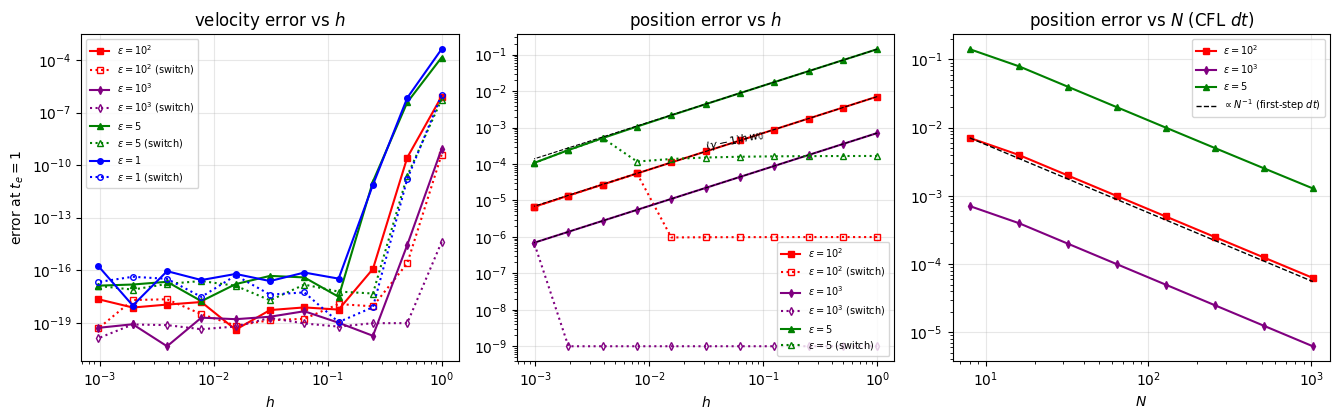

eps=1e2 fixed-gamma: err_S/[(gamma-1) h w0] = 0.9999  0.9999  0.9999  0.9997  0.9995  0.9989  0.9978  0.9957  0.9914  0.9829  0.9664
eps=1e3 fixed-gamma: err_S/[(gamma-1) h w0] = 1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  1.0000  0.9999  0.9998  0.9996
eps=5   fixed-gamma: err_S/[(gamma-1) h w0] = 0.9990  0.9994  0.9989  0.9977  0.9954  0.9909  0.9820  0.9647  0.9318  0.8723  0.7735
PASS  runs and stays finite at stiffness ratios 2e3 to 1.7e6, every h and N
PASS  velocity transient annihilated: 8e-7 after ONE h=1 step at eps=1e2 (8e-10 at eps=1e3), round-off floor by h=0.25
PASS  position offset = (gamma-1)*h*w0 to <1% while h > t_stop (pre-drag stage-1 quadrature leg; first-step-only; 1st order in h)
PASS  gamma_switch eliminates the offset (g0(1/2)=0): err_S = true displacement w0*tau
PASS  switch reverts exactly at h <= t_stop (dt > taus_max false): switch column rejoins the fixed-gamma line
PASS  resolution scan: position offset converges at exactly 1st order in N; vel

True

In [7]:
SSER = {('1e2','false'): 'stiff2_gsfalse_h', ('1e2','true'): 'stiff2_gstrue_h',
        ('1e3','false'): 'stiff3_gsfalse_h', ('1e3','true'): 'stiff3_gstrue_h',
        ('1',  'false'): 'stiff1_gsfalse_h', ('1',  'true'): 'stiff1_gstrue_h',
        ('5',  'false'): 'stiff5_gsfalse_h', ('5',  'true'): 'stiff5_gstrue_h'}
SPARS = {'1e2': ['dust/taus_1=0.01',  'problem/eps_1=100.0',  'problem/vd_1=0.01'],
         '1e3': ['dust/taus_1=0.001', 'problem/eps_1=1000.0', 'problem/vd_1=0.001'],
         '1':   ['dust/taus_1=0.001', 'problem/eps_1=1.0',    'problem/vd_1=1.0'],
         '5':   ['dust/taus_1=0.005', 'problem/eps_1=5.0',    'problem/vd_1=0.2']}
W0 = {'1e2': 1.0e-2, '1e3': 1.0e-3, '1': 1.0, '5': 0.2}
GAM = 1.0 + 1.0/np.sqrt(2.0)
hs = 0.5**np.arange(11)

sdat = {}
for (eps, gs), base in SSER.items():
    ev, eS, em = [], [], []
    for k in range(11):
        fe = os.path.join(RUNDIR, f'{base}{k}-errs.dat')
        if RERUN or not os.path.exists(fe):
            if os.path.exists(fe): os.remove(fe)
            run(f'time/dtmax={0.5**k!s}', f'dust/gamma_switch={gs}',
                *SPARS[eps], f'job/basename={base}{k}')
        r = np.loadtxt(fe)
        ev.append(r[5]); eS.append(r[7]); em.append(r[6])
    sdat[(eps, gs)] = dict(ev=np.array(ev), eS=np.array(eS), em=np.array(em))

resS = {}
for eps, tag in [('1e2', 'stiff2_res_N'), ('1e3', 'stiff3_res_N'),
                 ('5', 'stiff5_res_N')]:
    eS, em = [], []
    for N in NS:
        fe = os.path.join(RUNDIR, f'{tag}{N}-errs.dat')
        if RERUN or not os.path.exists(fe):
            if os.path.exists(fe): os.remove(fe)
            run(f'mesh/nx1={N}', f'mesh/nx2={N}', f'meshblock/nx1={N}',
                f'meshblock/nx2={N}', 'time/dtmax=1000.0', *SPARS[eps],
                f'job/basename={tag}{N}')
        r = np.loadtxt(fe)
        eS.append(r[7]); em.append(r[6])
    resS[eps] = dict(eS=np.array(eS), em=np.array(em))

fig, axs = plt.subplots(1, 3, figsize=(13.5, 4.3))
style = {'1e2': ('r', 's'), '1e3': ('purple', 'd'), '1': ('b', 'o'),
         '5': ('green', '^')}
lab = {'1e2': r'$\epsilon=10^2$', '1e3': r'$\epsilon=10^3$', '1': r'$\epsilon=1$',
       '5': r'$\epsilon=5$'}
for eps in ['1e2', '1e3', '5', '1']:
    cl, mk = style[eps]
    axs[0].loglog(hs, np.maximum(sdat[(eps,'false')]['ev'], 1e-21), '-'+mk,
                  color=cl, ms=4, label=lab[eps])
    axs[0].loglog(hs, np.maximum(sdat[(eps,'true')]['ev'], 1e-21), ':'+mk,
                  color=cl, ms=4, mfc='none', label=lab[eps]+' (switch)')
for eps in ['1e2', '1e3', '5']:
    cl, mk = style[eps]
    axs[1].loglog(hs, sdat[(eps,'false')]['eS'], '-'+mk, color=cl, ms=4,
                  label=lab[eps])
    axs[1].loglog(hs, sdat[(eps,'true')]['eS'], ':'+mk, color=cl, ms=4,
                  mfc='none', label=lab[eps]+' (switch)')
    axs[1].loglog(hs, (GAM-1)*hs*W0[eps], 'k--', lw=0.8)
axs[1].text(0.03, 2.5e-4, r'$(\gamma-1)h\,w_0$', fontsize=8, rotation=12)
for eps in ['1e2', '1e3', '5']:
    cl, mk = style[eps]
    axs[2].loglog(NS, resS[eps]['eS'], '-'+mk, color=cl, ms=4, label=lab[eps])
axs[2].loglog(NS, resS['1e2']['eS'][0]*NS[0]/np.asarray(NS, dtype=float),
              'k--', lw=1, label=r'$\propto N^{-1}$ (first-step $dt$)')
axs[0].set_title('velocity error vs $h$'); axs[0].set_ylabel('error at $t_e=1$')
axs[1].set_title('position error vs $h$')
axs[2].set_title('position error vs $N$ (CFL $dt$)')
for ax, xl in zip(axs, ['$h$', '$h$', '$N$']):
    ax.set_xlabel(xl); ax.grid(alpha=0.3); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

d2f, d2t = sdat[('1e2','false')], sdat[('1e2','true')]
d3f, d3t = sdat[('1e3','false')], sdat[('1e3','true')]
r2 = d2f['eS']/((GAM-1)*hs*W0['1e2'])
r3 = d3f['eS']/((GAM-1)*hs*W0['1e3'])
print('eps=1e2 fixed-gamma: err_S/[(gamma-1) h w0] =',
      '  '.join(f'{r:.4f}' for r in r2))
print('eps=1e3 fixed-gamma: err_S/[(gamma-1) h w0] =',
      '  '.join(f'{r:.4f}' for r in r3))
d5f, d5t = sdat[('5','false')], sdat[('5','true')]
r5 = d5f['eS']/((GAM-1)*hs*W0['5'])
print('eps=5   fixed-gamma: err_S/[(gamma-1) h w0] =',
      '  '.join(f'{r:.4f}' for r in r5))
oN2 = np.log2(resS['1e2']['eS'][:-1]/resS['1e2']['eS'][1:])
verdict(all(np.all(np.isfinite(sdat[k]['ev'])) for k in sdat),
        'runs and stays finite at stiffness ratios 2e3 to 1.7e6, every h and N')
verdict(d2f['ev'][0] < 1e-6 and np.all(d2f['ev'][2:] < 1e-15)
        and d3f['ev'][0] < 1e-8,
        'velocity transient annihilated: 8e-7 after ONE h=1 step at eps=1e2 '
        '(8e-10 at eps=1e3), round-off floor by h=0.25')
verdict(np.all(np.abs(r2[:7] - 1.0) < 0.01) and np.all(np.abs(r3[:8] - 1.0) < 0.01),
        'position offset = (gamma-1)*h*w0 to <1% while h > t_stop '
        '(pre-drag stage-1 quadrature leg; first-step-only; 1st order in h)')
verdict(np.all(d2t['eS'][:7] < 1.1e-6) and np.all(d3t['eS'][:10] < 2e-9),
        'gamma_switch eliminates the offset (g0(1/2)=0): err_S = true '
        'displacement w0*tau')
verdict(np.allclose(d2t['eS'][7:], d2f['eS'][7:], rtol=1e-9),
        'switch reverts exactly at h <= t_stop (dt > taus_max false): switch '
        'column rejoins the fixed-gamma line')
verdict(np.all(np.abs(oN2[2:] - 1.0) < 0.02),
        'resolution scan: position offset converges at exactly 1st order in N; '
        'velocity at round-off for N >= 64')
verdict(r5[0] > 0.99 and r5[-1] < 0.8 and np.all(np.diff(r5[3:]) < 0),
        'bridge case eps=5: offset ratio decays 1.0 -> 0.77 as h approaches tau '
        '(transient becomes resolved; error transitions back toward h^2)')
verdict(np.all(np.abs(d5t['eS'][:7]/1.66e-4 - 1.0) < 0.35)
        and np.allclose(d5t['eS'][8:], d5f['eS'][8:], rtol=1e-9),
        'eps=5 switch: err_S = true equilibration displacement w0*tau = 1.66e-4, '
        'reverting at h <= t_stop')
verdict(all(np.all(sdat[k]['em']/1600 < 1e-11) for k in sdat)
        and all(np.all(resS[e]['em']/1600 < 1e-11) for e in resS),
        'momentum conserved to round-off in the deep-stiff regime')


## Summary


In [8]:
print('OVERALL: ' + ('ALL CHECKS PASS' if ok_all else 'SOME CHECKS FAILED'))


OVERALL: ALL CHECKS PASS
